
<table width="100%">
  <td style="font-size:30px;text-align:left;background-color:rgba(150, 123, 182, 0.7);font-style:italic;">
    Explore superposition, entanglement and measurement in Qiskit.<br>
    <span style="font-size:25px;font-style:normal;">
      Borja Álvarez Reguera & Alicia de la Varga Cabero.
    </span>
  </td>
</table>

<p style="font-size:22px; font-weight:bold;">Simulation of the GHZ experiment.</p>

To explore superposition, entanglement and measurement we have decided to simulate the GHZ (Greenberger–Horne–Zeilinger) experiment proposed in 1989 that breaks EPR (Einstein-Podolsky-Rosen) paradox. Let's see how!

In this experiment, we simulate a 3 q-bit GHZ state, given by:

$$|\psi_{\text{GHZ}}\rangle = \frac{1}{\sqrt{2}}(|0,0,0\rangle + |1,1,1\rangle)$$

This state represents maximal entanglement among all three q-bits. None of them has a definite value individually since their states are fully correlated. **Measuring one q-bit immediately determines the outcome of the others, no matter how far apart they are**.

The GHZ state is conceptually linked to the 2022 Nobel Prize in Physics, awarded to *Alain Aspect, John F. Clauser, and Anton Zeilinger* for their groundbreaking experiments confirming that nature violates Bell inequalities and cannot be explained by any local hidden variable theory.
Our simulation captures the same core phenomenon: **quantum non-local correlations**.

<p style="font-size:18px; font-weight:bold;">What do we expect to measure?</p>
Using the relations between the Bloch Sphere poles (Pauli eigenkets):

$$|0\rangle = \frac{1}{\sqrt{2}}\left( |+\rangle + |-\rangle \right) = \frac{1}{\sqrt{2}}\left( |+i\rangle + |-i\rangle \right); \quad
|1\rangle = \frac{1}{\sqrt{2}}\left( |+\rangle - |-\rangle \right) = -\frac{i}{\sqrt{2}}\left( |+i\rangle - |-i\rangle \right)
$$

it is easy to rewrite:

$$
|\psi_{\text{GHZ}}\rangle =\frac{1}{2}\left( |+i, -i, -\rangle + |-i, +i, +\rangle + |+i, +i, -\rangle + |-i,-i, -\rangle\right) \Rightarrow \Sigma_C |\psi_{\text{GHZ}}\rangle = \left( \sigma_y \otimes \sigma_y \otimes \sigma_x \right) |\psi_{\text{GHZ}}\rangle = -|\psi_{\text{GHZ}}\rangle
$$
If we denote the values obtained when we measure $\sigma_x$ and $\sigma_y$ by $s_x^A$ and $s_y^A$ in, say, the q-bit A, we know that they can only take the values +1 or -1. Then we have (since $|\psi_{\text{GHZ}}\rangle$ is invariant under permutations of the three q-bits: A, B and C):

$$
s_y^A s_y^B s_x^C = -1 = s_x^A s_y^B s_y^C = s_y^A s_x^B s_y^C 
$$

Using our **classical** brain, we would say that each state provides a fixed value of each observable, including $\Sigma_C = -1$, but also $s^A_i$, $s^B_i$ and $s^C_i$ even though our quantum mechanical formulation does not allow us to predict their value with certainty. Then, multiplying the three previous equations (using that $(s_y^A)^2 = (s_y^B)^2 =(s_y^C)^2 = 1$) one gets:

$$
s_x^As_x^Bs_x^C \overset{\text{class}}{=} - 1 \Rightarrow \Sigma_{ABC} |\psi_{\text{GHZ}}\rangle = \left( \sigma_x \otimes \sigma_x \otimes \sigma_x \right) |\psi_{\text{GHZ}}\rangle \overset{\text{class}}{=} -|\psi_{\text{GHZ}}\rangle
$$

But this contradicts the **quantum** prediction. See that, rewritting $|\psi_{\text{GHZ}}\rangle$ in the $\{ |+\rangle, \ |-\rangle \}$ basis:
$$
|\psi_{\text{GHZ}}\rangle = \frac{1}{2}\left( |+,+,+\rangle + |+,-,-\rangle + |-,+,-\rangle + |-,-,+\rangle \right) \Rightarrow \Sigma_{ABC} |\psi_{\text{GHZ}}\rangle \overset{\text{qm}}{=} +|\psi_{\text{GHZ}}\rangle
$$

We are going to simulate these with quantum mechanichs rules expecting to obtain the quantum prediction, but it *can be reproduced in the lab* where the same result is seen. Then, the GHZ state beautifully demonstrates that quantum mechanics encodes information in correlations, not in individual particles.
This experiment reveals the same kind of non-classical behavior that underlies quantum teleportation, superdense coding, and the foundations of quantum computing itself.

<p style="font-size:18px; font-weight:bold;">Generating the GHZ state using Qiskit.</p>

In [1]:
# Import packages & classes
    # Classical Python Packages
import numpy as np
import matplotlib.pyplot as plt
    # Qiskit tools :)
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_histogram

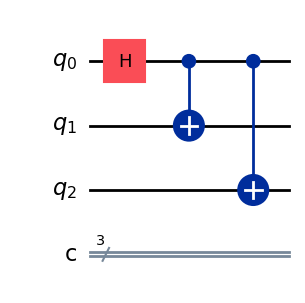

In [2]:
# GHZ circuit
    # Create a q-circuit with 3 q-bits (to generate the state) & 3 bits (to measure it)
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
    # Display the circuit
qc.draw('mpl')

If the 3 q-bits start in the ground state $|0\rangle$, after applying the Hadamard gate to the first q-bit $q_0$, the state becomes (assuming the q-bits are labeled $|q_0, q_1, q_2\rangle$):

$$
|\psi_1 \rangle = \left( H \otimes \text{Id} \otimes \text{Id} \right) |0,0,0\rangle = \frac{1}{\sqrt{2}}\left( |0,0,0\rangle + |1,0,0\rangle \right)
$$

Next, we apply a **CNOT** gate, where $q_0$ acts as the control q-bit and $q_1$ as the target. The resulting state is:

$$
|\psi_2\rangle = \text{CNOT}(q_0, q_1) |\psi_1\rangle = \frac{1}{\sqrt{2}}\left( |0,0,0\rangle + |1,1,0\rangle \right)
$$

Finally, a second **CNOT** gate is applied, where $q_0$ controls $q_2$. This results in the following state:

$$
|\psi_3\rangle = \text{CNOT}(q_0, q_2) |\psi_2\rangle = \frac{1}{\sqrt{2}}\left( |0,0,0\rangle + |1,1,1\rangle \right) = |\psi_{\text{GHZ}}\rangle
$$

At this point, we have generated the **GHZ state**, which is entangled and in a superposition of the $|0,0,0\rangle$ and $|1,1,1\rangle$ states.

Alternatively, the second CNOT can be replaced by another one where $q_1$ controls $q_2$:

$$
|\psi_4\rangle = \text{CNOT}(q_1, q_2) |\psi_1\rangle = \frac{1}{\sqrt{2}}\left( |0,0,0\rangle + |1,1,1\rangle \right) = |\psi_{\text{GHZ}}\rangle
$$

In either case, the result is the **GHZ state** $|\psi_{\text{GHZ}}\rangle$, which is entangled and in a superposition. Now let's visualize it.
<p style="font-size:18px; font-weight:bold;">Visualizating the GHZ state.</p>

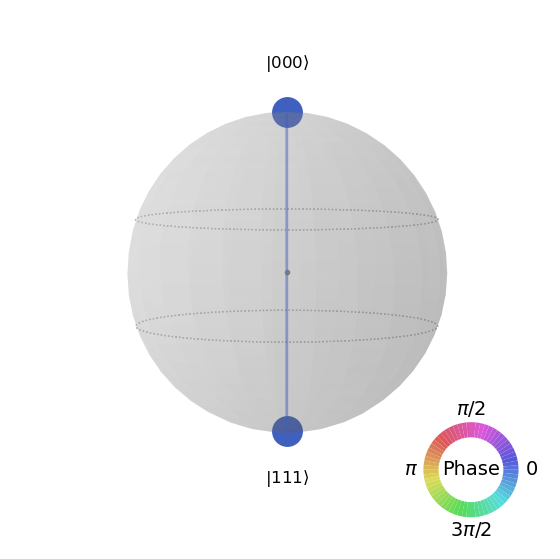

In [3]:
# Get statevector from GHZ circuit
state = Statevector.from_instruction(qc)
# Q-sphere visualization (global superposition)
plot_state_qsphere(state)

As expected, the q-sphere shows a superposition with no phase change between $|0,0,0\rangle$ and $|1,1,1\rangle$.

Note that we cannot represent this state via Bloch spheres, because the state is entangled and so the state of one q-bit depends on the state of the other q-bits. If we try to plot the state in the Bloch sphere, Qiskit will not give any information:

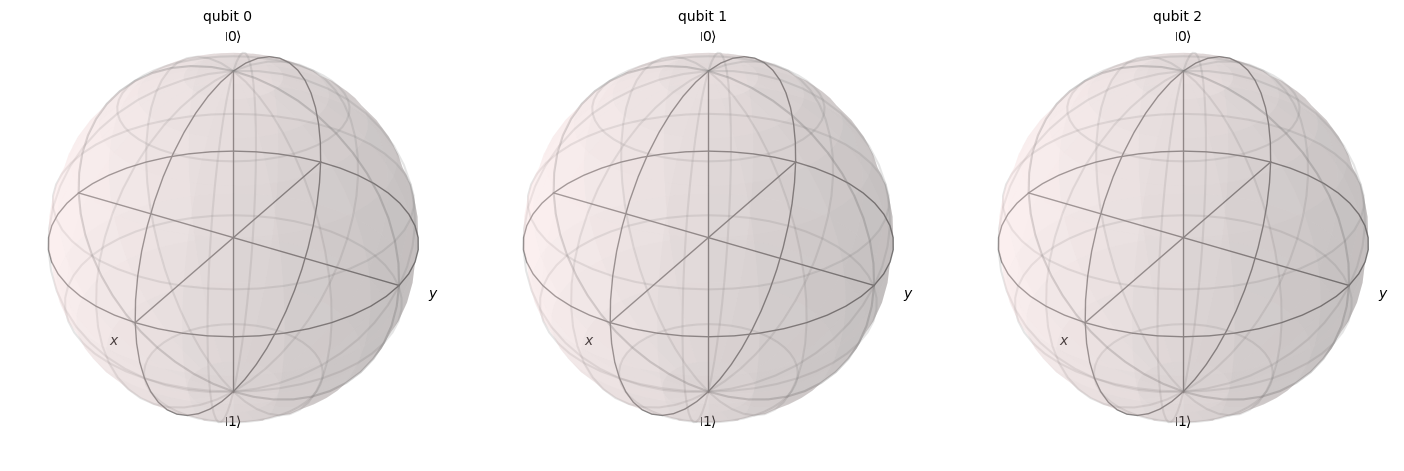

In [4]:
plot_bloch_multivector(state)

<p style="font-size:18px; font-weight:bold;">Measuring the GHZ state.</p>
Let's add some measurement devices conected to the classical bits.

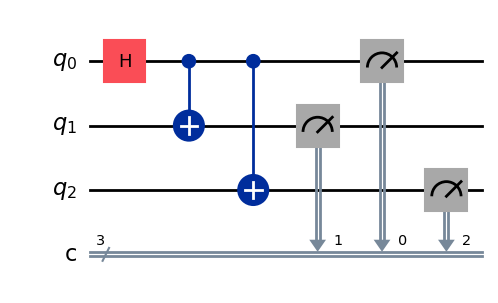

In [5]:
qc.measure([0,1,2], [0,1,2])
qc.draw('mpl')

Now let's simulate this circuit in order to make sure that the collapse will give $|0,0,0\rangle$ or $|1,1,1\rangle$, each one with probability $0.5$, as we expect.

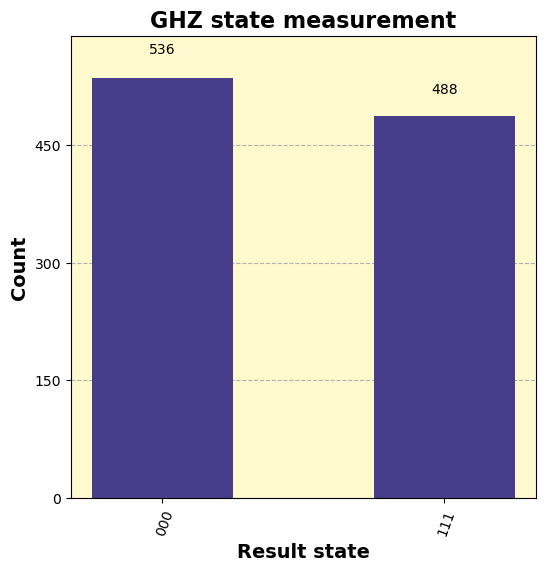

In [6]:
# Get counts dictionary for 1024 (default shots) simulations
counts = AerSimulator().run(qc).result().get_counts()
# Create the canvas for the histogram
fig = plt.figure(figsize=(6,6), clear=True)
hist_ax = fig.add_subplot(111)
hist_ax.set_facecolor('lemonchiffon')
hist_ax.set_title('GHZ state measurement', fontweight='bold', fontsize=16)
    # We don't know how to impose the text here instead of 'Count' for the final plot :(
hist_ax.set_ylabel('Number of counts', fontweight='bold', fontsize=14)
hist_ax.set_xlabel('Result state', fontweight='bold', fontsize=14)
# Create the histogram
plot_histogram(counts, color='darkslateblue', ax=hist_ax)

<p style="font-size:18px; font-weight:bold;">Measuring the observable $\Sigma_{ABC}$.</p>

Now that we know how to generate the desired state, we just need to to measure the observable. 
$$
\Sigma_{ABC} = \sigma_x \otimes \sigma_x \otimes \sigma_x
$$  
To do it, we must **project each q-bit** onto the eigenbasis of the Pauli-$X$ operator ($\sigma_x$), rather than the computational basis (eigenbasis of $\sigma_z$) $\{|0\rangle, |1\rangle\}$ used by the measurement devices. That's the reason why we must apply a **Hadamard gate** to each q-bit before measuring. The Hadamard transforms the eigenstates of $\sigma_x$ into those of $\sigma_z$ ($H \sigma_z H = \sigma_x$) according to:  

$$
H |0\rangle = |+\rangle, \quad H |1\rangle = |-\rangle,
$$ 

This means that measuring in the $Z$ basis after applying $H$ is **equivalent to measuring $\sigma_x$** in the original state. Therefore, the three Hadamard gates in the circuit do not change the physical content of the GHZ state —they simply rotate the measurement basis so that we can obtain the expected correlations for $\Sigma_{ABC}$.

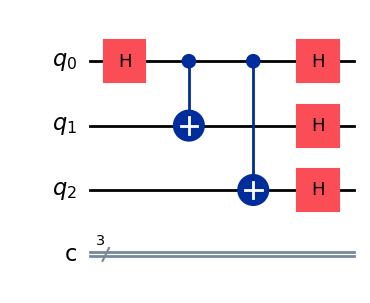

In [7]:
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.h(0)
qc.h(1)
qc.h(2)

qc.draw('mpl')

To get the final state after the new Hadamard gate we should operate a little bit:
$$
|\psi_5\rangle = \left( H \otimes H \otimes H \right)|\psi_{\text{GHZ}}\rangle = \frac{1}{\sqrt{2}}\left( \left( H \otimes H \otimes H \right)|0,0,0\rangle + \left( H \otimes H \otimes H \right)|1,1,1\rangle \right) =  \frac{1}{\sqrt{2}}\left( |+,+,+\rangle + |-,-,-\rangle \right)
$$
And using the relations:
$$
|+\rangle = \frac{1}{\sqrt{2}}\left( |0\rangle + |1\rangle \right); \quad |-\rangle = \frac{1}{\sqrt{2}}\left( |0\rangle - |1\rangle \right)
$$
One can get:
$$
|\psi_5\rangle = \frac{1}{2} \left( |0,0,0\rangle + |0,1,1\rangle + |1,0,1\rangle + |1,1,0\rangle \right) 
$$
Let's see what we have in the simulation:

In [8]:
state = Statevector.from_instruction(qc)
state.draw('latex')

<IPython.core.display.Latex object>

Time to add measure devices.

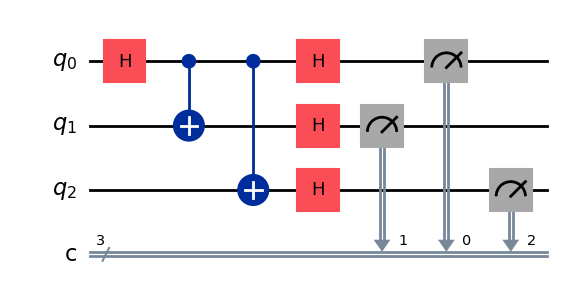

In [9]:
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw('mpl')

Finally, we estimate the **expectation value** of a $\Sigma_{ABC}$ using repeated measurements of $\sigma_z^{\otimes n}$ in the computational basis.

Each execution of the circuit produces a bitstring such as “010” or “111”. In the computational basis, each q-bit measurement corresponds to an eigenvalue of the Pauli-$Z$ operator ($\sigma_z$):

$$|0\rangle \rightarrow +1, \quad |1\rangle \rightarrow -1$$

For multiple q-bits, the eigenvalue associated with a given bitstring is the product of the eigenvalues of all measured q-bits, which can be expressed as:

$$\lambda_{\text{bitstring}} = (-1)^{\text{number of 1s}}$$

Therefore, every measurement outcome can be mapped to either $+1$ or $-1$, depending on how many q-bits collapsed to the state $|1\rangle$.

By repeating this process a large number of times (for instance, $2^{13}$ shots) and averaging all the obtained values, we estimate the **expected value** of the observable:

$$\langle \sigma_z^{\otimes n} \rangle = \frac{1}{N} \sum_{i=1}^{N} (-1)^{\text{number of 1s in } i}$$

This average converges to the theoretical quantum expectation value of the operator acting on the final state prepared by the circuit.


In [10]:
# Simulate 8192 = 2^13 times
counts = AerSimulator().run(qc, shots=8192).result().get_counts()
# Convert bitstrings to eigenvalues (-1)^number_of_1s
measure_values = [((-1) ** key.count('1')) * value for key, value in counts.items()]
# Compute expectation value
expectation_value = np.sum(measure_values) / 8192
# Check result within tolerance
if np.isclose(expectation_value, 1, atol=1e-3):
    print(f'Quantum simulations are non-local :) <Sigma_ABC> = {expectation_value:.4f}')
else: print(f'Revise the code, something is wrong dude :(  <Sigma_ABC> = {expectation_value:.4f}')

Quantum simulations are non-local :) <Sigma_ABC> = 1.0000
